In [206]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="gpt-5.4-mini"
)

In [207]:
from typing import TypedDict

class GraphState(TypedDict):

    resume_code: str
    job_description: str

    resume_keywords: list[str]
    jd_keywords: list[str]

    similar_keywords: list[str]

    remaining_resume_keywords: list[str]
    remaining_jd_keywords: list[str]

    similarity_score: int


### 2. Define the output schema



In [208]:
from pydantic import BaseModel, Field

class KeywordOutput(BaseModel):
    keywords: list[str] = Field(
        description="ATS-relevant keywords extracted from the input text."
    )


class KeywordPair(BaseModel):
    resume_keyword: str = Field(
        description="Keyword from the resume."
    )

    jd_keyword: str = Field(
        description="Matching keyword from the job description."
    )


class LLMMatchOutput(BaseModel):
    matches: list[KeywordPair] = Field(default_factory=list)

In [209]:
class SimilarKeywordsOutput(BaseModel):
    similar_keywords: list[str]
    remaining_resume_keywords: list[str]
    remaining_jd_keywords: list[str]
    similarity_score: int

### 3. Create a structured LLM


In [210]:
structured_llm = llm.with_structured_output(KeywordOutput)
structured_llm_match = llm.with_structured_output(LLMMatchOutput)

### 4. Write the extraction node


In [211]:
def extract_latex_keywords(state: GraphState):
    """
    Extracts ATS-relevant keywords from the provided LaTeX resume code.

    Args:
        state (GraphState): The current graph state containing the resume code.

    Returns:
        dict: A dictionary containing the extracted keywords that will be
        merged into the LangGraph state.
    """

    prompt = f"""
    You are an ATS resume keyword extraction expert.

    Extract ONLY ATS-relevant keywords from the following LaTeX resume.

    Include:
    - Programming languages
    - Frameworks
    - Libraries
    - Tools
    - Databases
    - Cloud platforms
    - DevOps technologies
    - APIs
    - AI/ML technologies
    - Software engineering concepts
    - Methodologies
    - Protocols
    - Explicitly mentioned soft skills

    Rules:
    - Ignore all LaTeX commands.
    - Ignore company names unless they are technologies.
    - Remove duplicates.
    - Preserve the original casing.
    - Do not infer technologies that are not explicitly mentioned.

    Resume:
    {state["resume_code"]}
    """

    result = structured_llm.invoke(prompt)

    return {
        "resume_keywords": result.keywords
    }


def extract_jd_keywords(state: GraphState):
    """
    Extracts ATS-relevant keywords from the provided Job Description of a Company.

    Args:
        state (GraphState): The current graph state containing the Job Description.

    Returns:
        dict: A dictionary containing the extracted keywords that will be
        merged into the LangGraph state.

    Rules:
        - Remove duplicates.
        - Ignore company names.
        - Ignore generic English words.
        - Preserve original wording.
    """

    prompt = f"""
    You are an ATS keyword extractor.

    Given the following Job Description, Extract only 
    explicitly mentioned technical skills,
    frameworks, tools, programming languages,
    APIs, concepts, databases, cloud technologies,
    and soft skills if they are explicitly stated.

    Return only the extracted keywords.

    Job Description:
    {state["job_description"]}
    """

    result = structured_llm.invoke(prompt)

    return {
        "jd_keywords": result.keywords
    }


### Normalize

In [212]:
def normalize(keyword):
    return keyword.lower().replace(".", "").strip()


def normalize_keywords(state: GraphState):
    """
    Normalize keywords and perform exact matching.
    """

    resume = {normalize(k): k for k in state["resume_keywords"]}
    jd = {normalize(k): k for k in state["jd_keywords"]}

    matched = set(resume.keys()) & set(jd.keys())

    similar_keywords = [resume[k] for k in matched]

    remaining_resume = [
        resume[k] for k in resume.keys() - matched
    ]

    remaining_jd = [
        jd[k] for k in jd.keys() - matched
    ]

    return {
        "similar_keywords": similar_keywords,
        "remaining_resume_keywords": remaining_resume,
        "remaining_jd_keywords": remaining_jd,
    }

### Embedding Similarity Search

In [213]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

model = SentenceTransformer("all-MiniLM-L6-v2")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [214]:
def embedding_match(state: GraphState):

    resume = state["remaining_resume_keywords"]
    jd = state["remaining_jd_keywords"]

    matched = []

    matched_resume = set()
    matched_jd = set()

    for r in resume:

        emb_r = model.encode(r)

        best_score = 0
        best_keyword = None

        for j in jd:

            emb_j = model.encode(j)

            score = cosine_similarity(
                [emb_r],
                [emb_j]
            )[0][0]

            if score > best_score:
                best_score = score
                best_keyword = j

        if best_score >= 0.80:

            matched.append(r)

            matched_resume.add(r)
            matched_jd.add(best_keyword)

    remaining_resume = [
        x for x in resume
        if x not in matched_resume
    ]

    remaining_jd = [
        x for x in jd
        if x not in matched_jd
    ]

    return {

        "similar_keywords":
            state["similar_keywords"] + matched,

        "remaining_resume_keywords":
            remaining_resume,

        "remaining_jd_keywords":
            remaining_jd
    }

In [215]:
def llm_match(state: GraphState):
    """
    Uses an LLM to compare only the remaining unmatched keywords.

    The LLM should match concepts, abbreviations,
    synonyms and ATS-equivalent technologies.
    """

    prompt = f"""
You are an ATS keyword comparison expert.

The keywords below have already gone through:

1. Exact matching
2. Embedding similarity matching

Only compare the remaining keywords.

Resume Keywords:
{state["remaining_resume_keywords"]}

Job Description Keywords:
{state["remaining_jd_keywords"]}

Instructions

- Match technologies with equivalent meaning.
- Match abbreviations.
- Match ATS-equivalent concepts.
- Ignore unrelated keywords.
- Do not invent matches.

Examples

RAG == Retrieval-Augmented Generation

LLM == Large Language Models

CI/CD == Continuous Integration

JWT == JWT Authentication

REST API == REST APIs

Return only the matched pairs.
"""

    result = structured_llm_match.invoke(prompt)

    matched_resume = [
        pair.resume_keyword
        for pair in result.matches
    ]

    matched_jd = [
        pair.jd_keyword
        for pair in result.matches
    ]

    remaining_resume = [
        keyword
        for keyword in state["remaining_resume_keywords"]
        if keyword not in matched_resume
    ]

    remaining_jd = [
        keyword
        for keyword in state["remaining_jd_keywords"]
        if keyword not in matched_jd
    ]

    similar_keywords = state["similar_keywords"] + matched_resume
    similarity_score = (
    len(similar_keywords)
    /
    (len(similar_keywords) + len(state["remaining_jd_keywords"]))
) * 100

    return {

        "similar_keywords":
            similar_keywords,

        "remaining_resume_keywords":
            remaining_resume,

        "remaining_jd_keywords":
            remaining_jd,

        "similarity_score":
            similarity_score
    }

In [216]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(GraphState)


graph.add_node('extract_latex_keywords', extract_latex_keywords)
graph.add_node('extract_jd_keywords', extract_jd_keywords)
graph.add_node('normalize_keywords', normalize_keywords)
graph.add_node('embedding_match', embedding_match)
graph.add_node('llm_match', llm_match)

graph.add_edge(START, 'extract_latex_keywords')
graph.add_edge(START, 'extract_jd_keywords')

graph.add_edge(['extract_latex_keywords', 'extract_jd_keywords'], 'normalize_keywords')

graph.add_edge('normalize_keywords', 'embedding_match')

graph.add_edge('embedding_match', 'llm_match')

graph.add_edge('llm_match', END)


workflow = graph.compile()



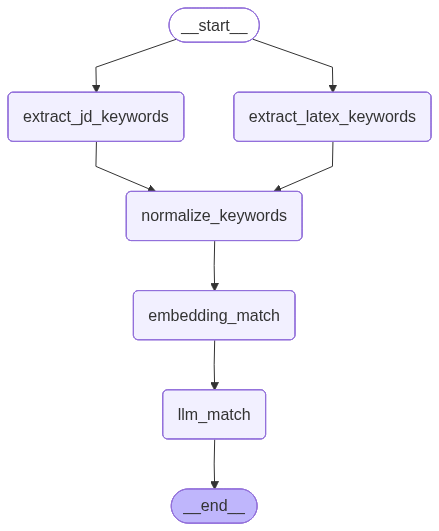

In [217]:
workflow

In [218]:
resume_code = r"""
%-------------------------
% Resume in Latex
% Author : Audric Serador
% Inspired by: https://github.com/sb2nov/resume
% License : MIT
%------------------------

\documentclass[a4paper,11pt]{article}

\usepackage{fontawesome5}
\usepackage{latexsym}
\usepackage[empty]{fullpage}
\usepackage{titlesec}
\usepackage{marvosym}
\usepackage[usenames,dvipsnames]{color}
\usepackage{verbatim}
\usepackage{enumitem}
\usepackage[hidelinks]{hyperref}
\usepackage{fancyhdr}
\usepackage[english]{babel}
\usepackage{tabularx}
\input{glyphtounicode}

\usepackage[default]{lato}

\pagestyle{fancy}
\fancyhf{}
\fancyfoot{}
\renewcommand{\headrulewidth}{0pt}
\renewcommand{\footrulewidth}{0pt}

\addtolength{\oddsidemargin}{-0.5in}
\addtolength{\evensidemargin}{-0.5in}
\addtolength{\textwidth}{1in}
\addtolength{\topmargin}{-.5in}
\addtolength{\textheight}{1.0in}

\urlstyle{same}
\raggedbottom
\raggedright
\setlength{\tabcolsep}{0in}

\titleformat{\section}{
  \vspace{-4pt}\scshape\raggedright\large
}{}{0em}{}[\color{black}\titlerule\vspace{-5pt}]

\pdfgentounicode=1

\newcommand{\resumeItem}[1]{
  \item\small{{#1 \vspace{-2pt}}}
}

\newcommand{\resumeSubheading}[4]{
  \vspace{-2pt}\item
    \begin{tabular*}{0.97\textwidth}[t]{l@{\extracolsep{\fill}}r}
      \textbf{#1} & #2 \\
      \textit{\small#3} & \textit{\small #4} \\
    \end{tabular*}\vspace{-7pt}
}

\newcommand{\resumeProjectHeading}[2]{
    \item
    \begin{tabular*}{0.97\textwidth}{l@{\extracolsep{\fill}}r}
      \small#1 & #2 \\
    \end{tabular*}\vspace{-7pt}
}

\newcommand{\resumeSubHeadingListStart}{\begin{itemize}[leftmargin=0.15in, label={}]}
\newcommand{\resumeSubHeadingListEnd}{\end{itemize}}
\newcommand{\resumeItemListStart}{\begin{itemize}}
\newcommand{\resumeItemListEnd}{\end{itemize}\vspace{-5pt}}

\begin{document}

%----------HEADING----------%

\begin{center}
    {\Huge \scshape Tousif Tamboli} \\ \vspace{5pt}
    \small
    7666839558 $|$
    \href{mailto:tousiftamboli3@gmail.com}{\underline{tousiftamboli3@gmail.com}} $|$
    \href{https://github.com/TousifTamboli}{\underline{github.com/TousifTamboli}} \\[2pt]
    \small
    \href{https://leetcode.com/u/TousifTamboli/}{\underline{leetcode.com/TousifTamboli}} $|$
    \href{https://www.linkedin.com/in/tousif-tamboli-545357221}{\underline{linkedin.com/in/tousif-tamboli-545357221}} $|$
    \href{https://www.tousif.online/}{\underline{my-portfolio.com}}
    
\end{center}

%-----------EXPERIENCE-----------%

\section{Experience}
  \resumeSubHeadingListStart

    \resumeSubheading
      {Software Developer Intern}{\small Dec 2025 -- Jun 2026}
      {Tortus AI}{Remote}

     \resumeItemListStart
        \resumeItem{Engineered and maintained scalable backend services using NodeJs, MongoDB, integrated an AI-powered chatbot into the production website using LLM APIs; collaborated cross-functionally in an Agile/Scrum environment, contributing to sprint deliverables for a platform serving 500k+ users with 99.9\% uptime.}
        
        \resumeItem{Architected and automated CI/CD pipelines using Docker, Docker Compose, and GitHub Actions, streamlining multi-environment deployments; managed DevOps infrastructure, reducing deployment overhead by 35\% and accelerating release cycles across the engineering team.}
    \resumeItemListEnd

  \resumeSubHeadingListEnd

%-----------PROJECTS-----------%

\section{Projects}
    \resumeSubHeadingListStart

      \resumeProjectHeading
          {\textbf{\href{https://github.com/TousifTamboli/youtube-summarize-rag-langchain}{\underline{YouTube Video Analyzer — AI/LLM-Powered RAG Application}}}}{\small Jun 2026}

          \resumeItemListStart
            \resumeItem{Built a full-stack RAG application with a React.js frontend and Python/FastAPI backend, enabling real-time NLP-based video content processing via LangChain, HuggingFace Embeddings, OpenAI LLMs, and the YouTube Transcript API; containerized with Docker for team collaboration.}
            \resumeItem{Eliminated manual video review by allowing users to generate AI summaries and hold conversational Q\&A sessions with any YouTube video, reducing content review time by an estimated 60\%.}
        \resumeItemListEnd

        \resumeProjectHeading
          {\textbf{\href{https://github.com/TousifTamboli/web-based-rag-using-langchain}{\underline{RAG Chatbot for Stripe Privacy \& Policy Intelligence}}}}{\small Jun 2026}

          \resumeItemListStart
            \resumeItem{Identified that Stripe's compliance information was fragmented across 35+ web pages; built a production-ready RAG chatbot using Python, LangChain, semantic search, OpenAI and Claude LLMs over scraped policy documents; containerized with Docker for cross-team deployment.}
            \resumeItem{Consolidated all policy sources into a single conversational AI-powered interface, reducing average retrieval time by 40\% and improving client satisfaction by 20\%.}
        \resumeItemListEnd

      \resumeProjectHeading
          {\textbf{\href{https://github.com/TousifTamboli/tp-cell-system}{\underline{University Recruitment Automation Suite — MERN Stack}}}}{\small Feb 2026 -- Mar 2026}

          \resumeItemListStart
            \resumeItem{Built a centralized campus recruitment platform using React.js, Node.js, Express.js, MongoDB, and Redis with JWT authentication and RBAC, reducing REST API dashboard response times by 40\% through caching and query optimization.}
            \resumeItem{Automated end-to-end recruitment workflows including application tracking, shortlisting, analytics reporting, audit logging, and CSV exports; followed Agile/Scrum sprint delivery with peer code reviews.}
          \resumeItemListEnd

      \resumeProjectHeading
          {\textbf{\href{https://github.com/TousifTamboli/govguidebot}{\underline{GovGuideBot — AI-Powered NLP Document Assistance System}}}}{\small Jun 2024 -- Jun 2025}

          \resumeItemListStart
            \resumeItem{Designed an RAG pipeline using Python and Web - Crawler with Named Entity Recognition (NER) to extract structured information from government documents, reducing manual lookup effort by 50\%.}
            \resumeItem{Built an intent-processing engine that parses natural-language queries and generates step-by-step procedural guidance; Dockerized for cloud-native open-source.}
          \resumeItemListEnd

    \resumeSubHeadingListEnd

%-----------SKILLS-----------%

\section{Technical Skills}

 \begin{itemize}[leftmargin=0.15in, label={}]
    \small{\item{

     \textbf{Languages}{: C++, Python, JavaScript, SQL} \\

     \textbf{AI / ML}{: LLMs, RAG, LangChain, LangGraph, HuggingFace, Prompt Engineering} \\

     \textbf{Frontend}{: React.js, Next.js, Tailwind CSS} \\

     \textbf{Backend}{: Node.js, Express.js, FastAPI, REST APIs, Redis, Microservices} \\

     \textbf{Databases}{: MongoDB, MySQL} \\

     \textbf{DevOps \& Cloud}{: Docker, GitHub Actions, AWS, CI/CD, Linux} \\

     \textbf{Practices}{: Agile/Scrum, System Design, Code Reviews, GitHub Copilot, Unit Testing}

    }}
 \end{itemize}

 %-----------EDUCATION-----------%

\section{Education}
  \resumeSubHeadingListStart
    \resumeSubheading
      {Savitribai Phule Pune University}{\small 2022 -- 2026}
      {Bachelor of Technology in Computer Science (Data Science)}{CGPA: 8.9}
  \resumeSubHeadingListEnd

%-----------ACHIEVEMENTS-----------%

\section{Achievements}

\resumeItemListStart
\resumeItem{\textbf{LeetCode and Hackathon:} Solved 800+ problems with a Contest Rating of 1650+, TOP 5\% in E-CELL IIT Bombay Hackathon}
\resumeItem{Delivered 5+ freelance full-stack web development projects end-to-end independently, meeting strict client requirements and deadlines across React.js, Node.js, and cloud deployment.}
\resumeItemListEnd

\end{document}
"""

In [219]:
job_description = r"""
About The Role

We are looking for a passionate and driven Al/ML Intern to

join our team. This role is ideal for recent graduates who are

eager to work on real-world Al applications, including LLM

integrations, modern Al frameworks, and scalable backend

systems.

You will gain hands-on experience building intelligent

systems using cutting-edge tools and contribute to

production-level Al solutions.

Key Responsibilities

 Work on real-world AI/ML problems with a strong focus on

problem-solving and analytical thinking

이

Build and integrate LLM-based applications

Implement RAG (Retrieval-Augmented Generation) pipelines

Work with LangChain, LangGraph, and modern AI

orchestration tools

 Develop and integrate REST APIs for Al services

Collaborate on backend systems using Python frameworks

like FastAPI or Django

 Understand and contribute to web architecture and system

design

Work with structured and unstructured data

Implement and optimize embeddings and vector search

Use and manage vector databases

Experiment with transformer-based models

Write clean, modular, and reusable code using OOP

principles

Required Skills & Qualifications

Core Requirements

 Strong problem-solving skills
 Hands-on practical experience in core Python
 Good understanding of Object-Oriented Programming

(OOP)

 Familiarity with modern Al tools and frameworks
 Understanding of REST APIs and web services

이 Basic knowledge of web architecture

AI/ML & Data Skills

 Understanding of:

이

Embeddings

Transformers

RAG pipelines

Experience Or Exposure To

LangChain / LangGraph

LLM integration (OpenAI, open-source models, etc.)

Familiarity With

Vector Databases (e.g., FAISS, Pinecone, Chroma)

Backend & Database Skills

Experience With At Least One Python Backend Rramework

FastAPI or Django

Knowledge Of

SQL databases (MySQL, PostgreSQL, etc.)

 NoSQL databases (MongoDB, etc.)

Good To Have Javascript Skills

 Basic to intermediate knowledge of JavaScript (ES6+)

and/or TypeScript

 Understanding of asynchronous programming (Promises,

async/await)

Familiarity with frontend frameworks/libraries like React.js

(preferred but not mandatory)

Ability to integrate frontend with backend APIs (REST API

consumption)

Basic Understanding Of

이

이

Component-based architecture

State management concepts

Experience with building simple Ul interfaces for Al

applications (chat interfaces, dashboards, etc.) is a plus

Education Requirements

Recently Graduated With One Of The Following

 B.Tech / B.E. in Computer Science, IT, or related field
 MCA (Master of Computer Applications)

M.Sc. IT / Computer Science

Any other relevant Computer Science Degree.

Good to Have

Experience with deploying ML/AI models

Exposure to cloud platforms (AWS, GCP, Azure)

Knowledge of Docker or containerization

Personal or academic Al projects (GitHub portfolio is a plus)

What You'll Gain

Hands-on experience with production-level Al systems

Exposure to cutting-edge Al tools and LLM ecosystems

Mentorship from experienced engineers

Opportunity for full-time conversion based on performance

Note: This is a unpaid internship.Skills: llm,ai intern,python,langchain,rag,sql"""

In [220]:
initial_state = {
    'resume_code': resume_code,
    'job_description': job_description
}

result = workflow.invoke(initial_state)

print(result)

{'resume_code': "\n%-------------------------\n% Resume in Latex\n% Author : Audric Serador\n% Inspired by: https://github.com/sb2nov/resume\n% License : MIT\n%------------------------\n\n\\documentclass[a4paper,11pt]{article}\n\n\\usepackage{fontawesome5}\n\\usepackage{latexsym}\n\\usepackage[empty]{fullpage}\n\\usepackage{titlesec}\n\\usepackage{marvosym}\n\\usepackage[usenames,dvipsnames]{color}\n\\usepackage{verbatim}\n\\usepackage{enumitem}\n\\usepackage[hidelinks]{hyperref}\n\\usepackage{fancyhdr}\n\\usepackage[english]{babel}\n\\usepackage{tabularx}\n\\input{glyphtounicode}\n\n\\usepackage[default]{lato}\n\n\\pagestyle{fancy}\n\\fancyhf{}\n\\fancyfoot{}\n\\renewcommand{\\headrulewidth}{0pt}\n\\renewcommand{\\footrulewidth}{0pt}\n\n\\addtolength{\\oddsidemargin}{-0.5in}\n\\addtolength{\\evensidemargin}{-0.5in}\n\\addtolength{\\textwidth}{1in}\n\\addtolength{\\topmargin}{-.5in}\n\\addtolength{\\textheight}{1.0in}\n\n\\urlstyle{same}\n\\raggedbottom\n\\raggedright\n\\setlength{\\ta

In [221]:
print(result['similarity_score'])

49.39759036144578
